# 1D Schrodinger equation eigensolver

This notebook is the working demo for `Eigensolver_1Dimension.py`: a finite-difference
eigensolver for the time-independent Schrodinger equation in one dimension. It builds
the Hamiltonian on a grid, diagonalizes it, plots the eigenfunctions and the energy
spectrum, and checks the result against the two potentials where I actually know the
right answer (infinite square well, harmonic oscillator).

Full derivation of the finite-difference stencil and the analytic spectra for the 9
potentials implemented here is in `Eigensolver_1Dimensional.pdf`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

from Eigensolver_1Dimension import (
    Schrodinger_solver,
    V_HarmonicOscillator,
    V_DoubleWell,
    V_InfiniteSquareWell,
    plot_wavefunctions,
    plot_energy_levels,
)

## Harmonic oscillator

Textbook case: $V(x) = \tfrac{1}{2} m \omega^2 x^2$, $E_n = \hbar\omega(n+\tfrac12)$.

In [1]:
x, eigvals, eigvecs = Schrodinger_solver(
    V_pot=partial(V_HarmonicOscillator, omega=1.0, m=1.0),
    x_min=-8.0, x_max=8.0,
    N=2000,
    num_eigvals=6,
)

for n, En in enumerate(eigvals):
    print(f"n={n}, E = {En:.6f}")

n=0, E = 0.500000
n=1, E = 1.500000
n=2, E = 2.500000
n=3, E = 3.500000
n=4, E = 4.500000
n=5, E = 5.500000


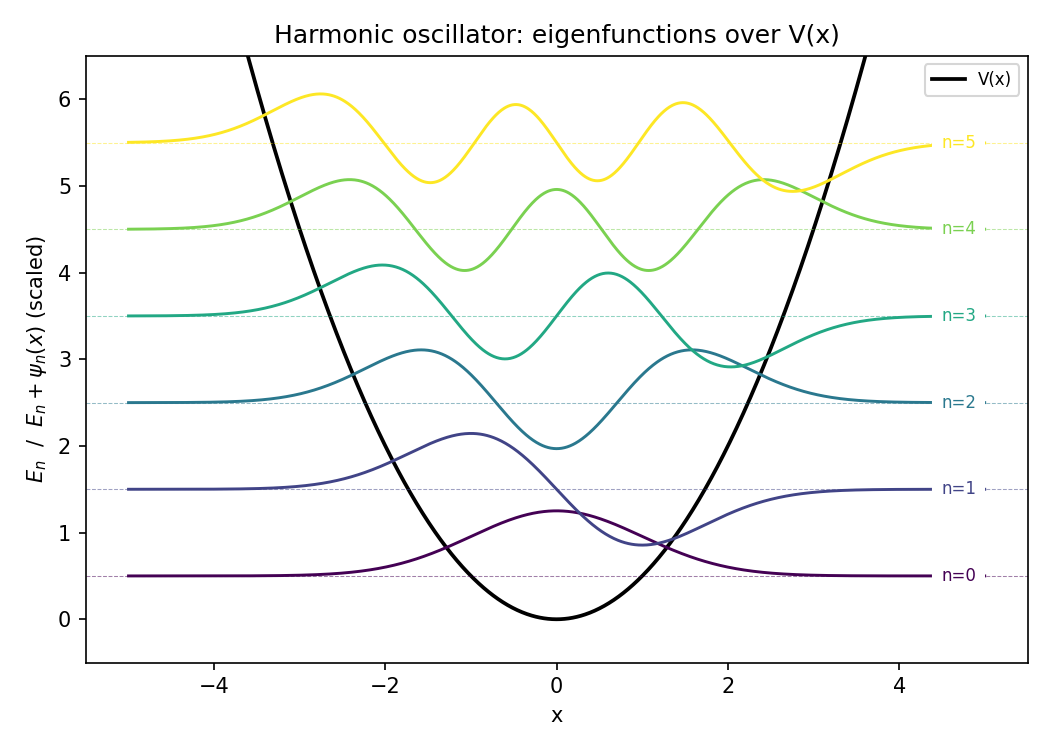

In [1]:
plot_wavefunctions(
    x, eigvals, eigvecs, partial(V_HarmonicOscillator, omega=1.0, m=1.0),
    n_states=6, scale=1.0, x_range=(-5, 5), y_range=(-0.5, 6.5),
    title="Harmonic oscillator: eigenfunctions over V(x)",
)
plt.show()

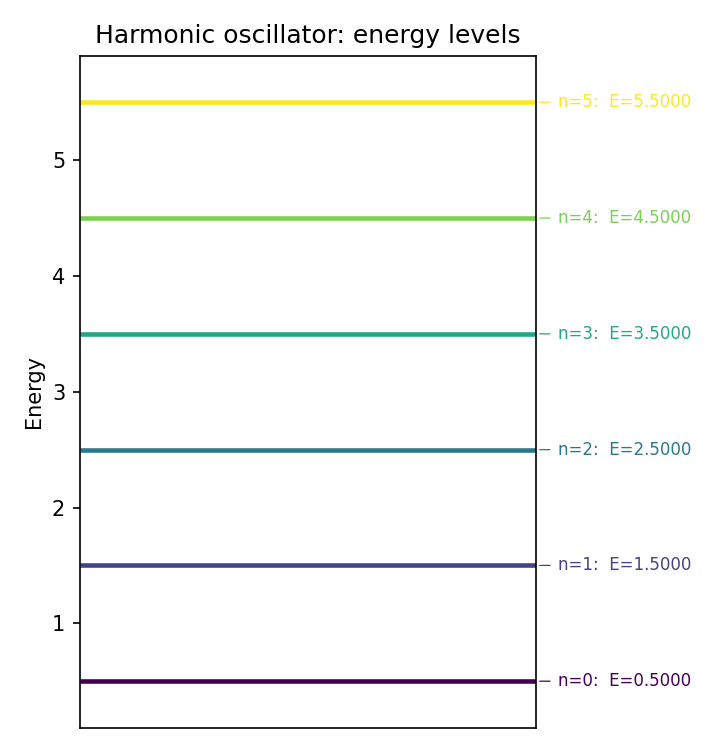

In [1]:
plot_energy_levels(eigvals, n_states=6, title="Harmonic oscillator: energy levels")
plt.show()

## Quartic double well

$V(x) = V_0 (x^2 - a^2)^2$. No closed form here, but it is a good stress test: the two
wells at $x=\pm a$ each support their own near-degenerate levels, split by tunneling
through the central barrier. The splitting should shrink fast as you go to lower energy
relative to the barrier height.

In [1]:
x, eigvals, eigvecs = Schrodinger_solver(
    V_pot=partial(V_DoubleWell, a=1.5, V0=7.0),
    x_min=-4.0, x_max=4.0,
    N=3000,
    num_eigvals=6,
)

for n, En in enumerate(eigvals):
    print(f"n={n}, E = {En:.6f}")
print(f"Tunneling splitting n=0,1: {eigvals[1]-eigvals[0]:.3e}")
print(f"Tunneling splitting n=2,3: {eigvals[3]-eigvals[2]:.3e}")

n=0, E = 5.495856
n=1, E = 5.495862
n=2, E = 15.970248
n=3, E = 15.971142
n=4, E = 25.468109
n=5, E = 25.518574
Tunneling splitting n=0,1: 5.822e-06
Tunneling splitting n=2,3: 8.935e-04


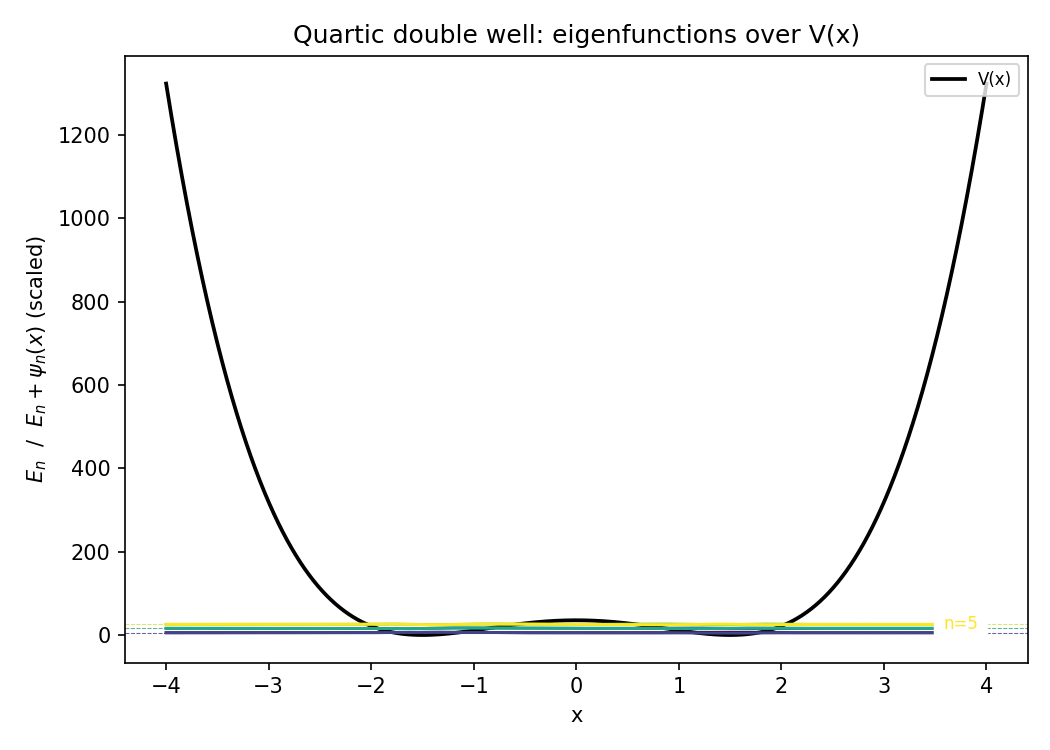

In [1]:
ax = plot_wavefunctions(
    x, eigvals, eigvecs, partial(V_DoubleWell, a=1.5, V0=7.0),
    n_states=6, scale=3.0, x_range=(-3.2, 3.2), y_range=(-2, 29),
    title="Quartic double well: eigenfunctions over V(x)",
)
ax.legend(loc="lower right", fontsize=8)
plt.show()

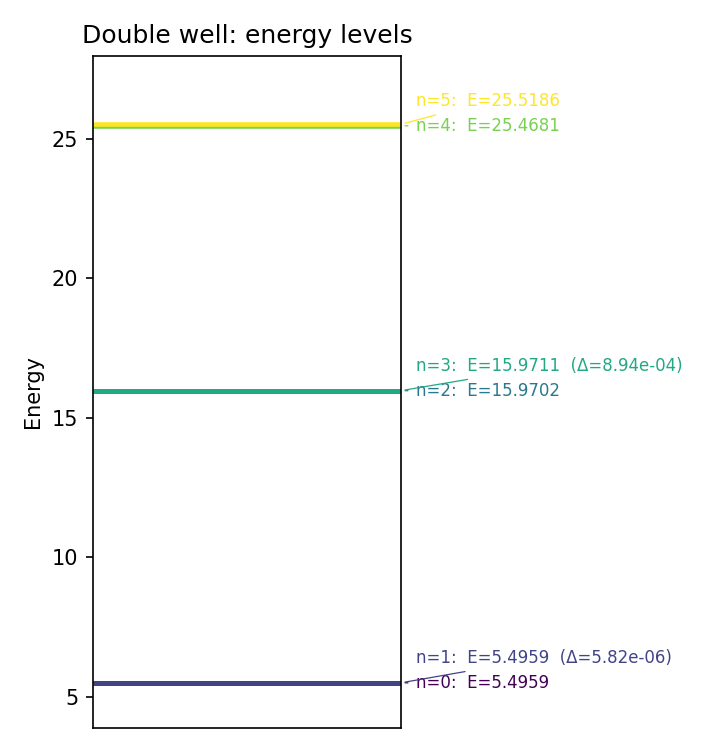

In [1]:
plot_energy_levels(eigvals, n_states=6, title="Double well: energy levels")
plt.show()

## Validation against analytic solutions

`validate_1d.py` runs this comparison as a standalone script. Reproduced here:

**Infinite square well** ($L=10$, $\hbar=m=1$): $E_n = n^2\pi^2\hbar^2/(2mL^2)$

In [1]:
from validate_1d import validate_infinite_square_well, validate_harmonic_oscillator, print_table

ns, num, an, err = validate_infinite_square_well()
print_table("Infinite square well (L=10, hbar=m=1)", ns, num, an, err)


Infinite square well (L=10, hbar=m=1)
  n        numeric       analytic   rel. error
  1     0.04935566     0.04934802    1.548e-04
  2     0.19742264     0.19739209    1.548e-04
  3     0.44420095     0.44413220    1.548e-04
  4     0.78969057     0.78956835    1.548e-04
  5     1.23389152     1.23370055    1.548e-04
  6     1.77680378     1.77652879    1.548e-04


**Harmonic oscillator** ($\omega=m=\hbar=1$): $E_n = \hbar\omega(n+\tfrac12)$

In [1]:
ns, num, an, err = validate_harmonic_oscillator()
print_table("Harmonic oscillator (omega=m=hbar=1)", ns, num, an, err)


Harmonic oscillator (omega=m=hbar=1)
  n        numeric       analytic   rel. error
  0     0.50000000     0.50000000    8.623e-11
  1     1.50000000     1.50000000    1.995e-10
  2     2.50000000     2.50000000    4.267e-10
  3     3.50000000     3.50000000    7.696e-10
  4     4.49999999     4.50000000    1.225e-09
  5     5.49999999     5.50000000    1.796e-09


The harmonic oscillator agrees to ~9-10 significant figures. The infinite square well
sits at a constant relative error around $1.5\times10^{-4}$ for every level - a flat
offset, not something that grows with $n$. That flatness is the signature of the
boundary-stencil limitation documented in `d2dx2_matrix`'s docstring, not of the
Lanczos solver or the discretization in the bulk. The next cell shows why.

## Convergence check: why the square well sits at a constant error

The interior 5-point stencil is 4th order ($O(dx^4)$), so a correctly-implemented
Dirichlet FD scheme should converge as $N^{-4}$. I chose to reuse the same central
stencil at the two rows adjacent to each boundary instead of the one-sided formulas I
derived by hand (`Eigensolver_1Dimensional.pdf`, page 2), because mixing the two breaks
the exact symmetry of $H$ (a one-sided row and its neighbor's central row do not assign
matching off-diagonal coefficients to each other, so $H \neq H^\dagger$ anymore). The
trade-off is that those two rows only carry $O(dx^2)$ local accuracy, which caps the
*global* convergence at $O(dx)$ for any state with non-negligible slope at the boundary -
exactly what the square well has, and exactly what shows up below.

N=  200   rel. error=1.556e-03
N=  400   rel. error=7.759e-04
N=  800   rel. error=3.873e-04
N= 1600   rel. error=1.935e-04
N= 3200   rel. error=9.672e-05


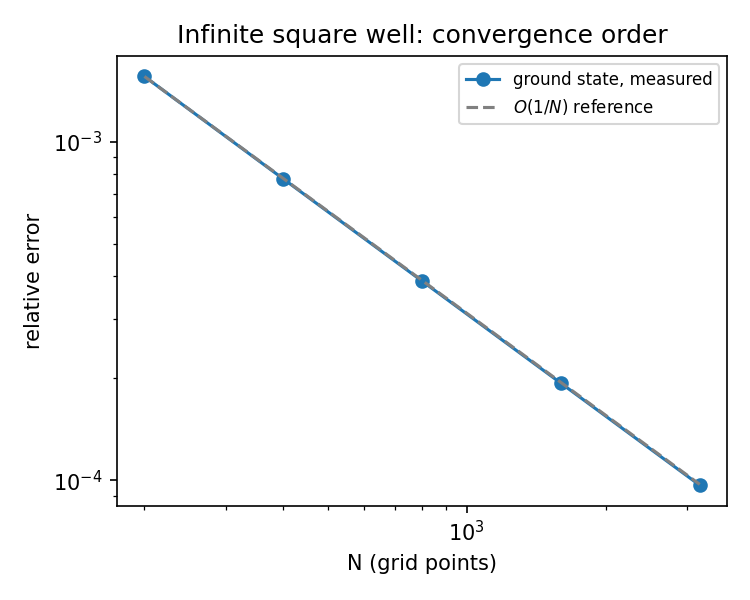

In [1]:
from validate_1d import convergence_study_isw

Ns, errs = convergence_study_isw()
for N, e in zip(Ns, errs):
    print(f"N={N:>5}   rel. error={e:.3e}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.loglog(Ns, errs, "o-", label="ground state, measured")
ax.loglog(Ns, errs[0] * Ns[0] / Ns, "--", color="gray", label=r"$O(1/N)$ reference")
ax.set_xlabel("N (grid points)")
ax.set_ylabel("relative error")
ax.set_title("Infinite square well: convergence order")
ax.legend(fontsize=8)
plt.show()

The measured points track the $O(1/N)$ line almost exactly, confirming first-order (not
fourth-order) global convergence for this potential. In practice this just means: for
potentials where $\psi$ has real weight at the domain edges (square wells, linear
potentials), use a generous $N$; for potentials that decay to ~0 before the edges
(oscillators, wells, soft-Coulomb with a wide enough domain) the effect is negligible, as
seen above where the harmonic oscillator hits $10^{-9}$-$10^{-10}$ with the same solver.